In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

INPUT_SHAPE = (128, 1)  # 128 time steps, 1 feature (Magnitude)
BATCH_SIZE = 64
EPOCHS = 50             # We will use Early Stopping, so 50 is a safe upper limit
MODEL_SAVE_PATH = "models/autoencoder_v1.h5"

# Ensure models folder exists
if not os.path.exists("models"):
    os.makedirs("models")

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [3]:
# Load Data
print("Loading processed data...")
X_train = np.load("processed_data/X_train.npy")
X_test_normal = np.load("processed_data/X_test_normal.npy")
X_test_faulty = np.load("processed_data/X_test_faulty.npy")

print(f"Train Shape: {X_train.shape}")
print(f"Test (Normal) Shape: {X_test_normal.shape}")
print(f"Test (Faulty) Shape: {X_test_faulty.shape}")

Loading processed data...
Train Shape: (269999, 128, 1)
Test (Normal) Shape: (67499, 128, 1)
Test (Faulty) Shape: (674999, 128, 1)


In [4]:
def build_autoencoder(input_shape):
    input_layer = layers.Input(shape=input_shape)

    # --- ENCODER (Compression) ---
    # 128 -> 64
    x = layers.Conv1D(32, kernel_size=3, strides=2,
                      padding='same', activation='relu')(input_layer)
    # 64 -> 32
    x = layers.Conv1D(16, kernel_size=3, strides=2,
                      padding='same', activation='relu')(x)
    # 32 -> 16 (The Latent Bottleneck)
    encoded = layers.Conv1D(8, kernel_size=3, strides=2,
                            padding='same', activation='relu')(x)

    # --- DECODER (Reconstruction) ---
    # 16 -> 32
    x = layers.Conv1DTranspose(
        8, kernel_size=3, strides=2, padding='same', activation='relu')(encoded)
    # 32 -> 64
    x = layers.Conv1DTranspose(
        16, kernel_size=3, strides=2, padding='same', activation='relu')(x)
    # 64 -> 128
    x = layers.Conv1DTranspose(
        32, kernel_size=3, strides=2, padding='same', activation='relu')(x)

    # OUTPUT LAYER
    # Sigmoid activation forces output to be between 0 and 1 (matching our normalization)
    decoded = layers.Conv1D(
        1, kernel_size=3, padding='same', activation='sigmoid')(x)

    # Create Model
    autoencoder = models.Model(input_layer, decoded)
    return autoencoder


# Instantiate and Compile
model = build_autoencoder(INPUT_SHAPE)
# Mean Squared Error is best for reconstruction
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 64, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 32, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 16, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 32, 8)          │           200 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 64, 16)         │           400 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 128, 32)        │         1,568 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 128, 1)         │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping to prevent wasting time
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("--- Starting Training ---")
history = model.fit(
    X_train, X_train,              # Input = Target (Self-Supervised)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    # Validate on unseen HEALTHY data
    validation_data=(X_test_normal, X_test_normal),
    callbacks=[early_stopping],
    shuffle=True
)

# Save the final trained brain
model.save(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

--- Starting Training ---
Epoch 1/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 0.0036 - val_loss: 8.6590e-04
Epoch 2/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0011 - val_loss: 8.3110e-04
Epoch 3/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0011 - val_loss: 8.1214e-04
Epoch 4/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0010 - val_loss: 7.9544e-04
Epoch 5/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0010 - val_loss: 7.8838e-04
Epoch 6/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0010 - val_loss: 7.7622e-04
Epoch 7/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.0010 - val_loss: 7.7046e-04
Epoch 8/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0010 - val_loss: 7.6208e-04
Epoch 9/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 9.9447e-04 - val_loss: 7.4922e-04
Epoch 10/50
4219/4219 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 9.6862e-04 - val_loss: 7.3956e-04
Epoch 11/50
4219/4219 ━━━━━━━━━━━━━

✅ Model saved to models/autoencoder_v1.h5


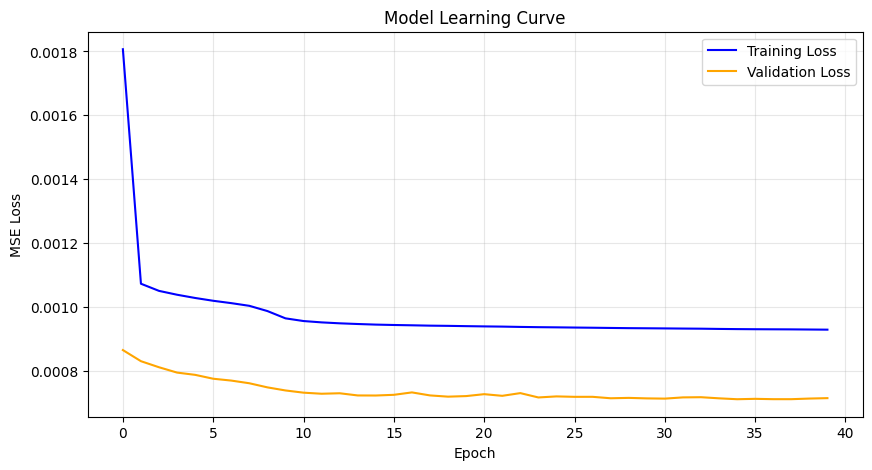

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Learning Curve')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


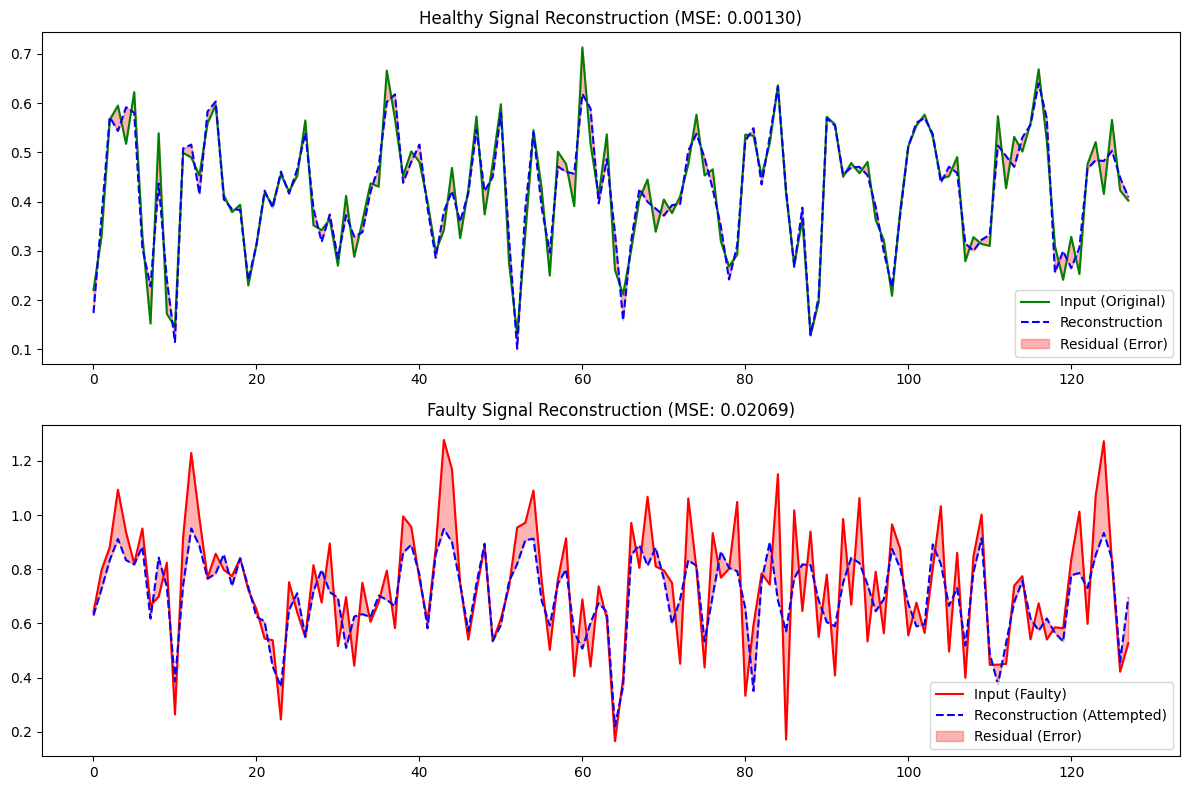

In [ ]:
# Pick a random Healthy sample
idx_normal = np.random.randint(0, len(X_test_normal))
sample_normal = X_test_normal[idx_normal:idx_normal+1]
reconst_normal = model.predict(sample_normal)

# Pick a random Faulty sample
idx_faulty = np.random.randint(0, len(X_test_faulty))
sample_faulty = X_test_faulty[idx_faulty:idx_faulty+1]
reconst_faulty = model.predict(sample_faulty)

# Plot Comparison
plt.figure(figsize=(12, 8))

# Plot Healthy
plt.subplot(2, 1, 1)
plt.plot(sample_normal[0], label="Input (Original)", color='green')
plt.plot(reconst_normal[0], label="Reconstruction", color='blue', linestyle='--')

# Highlight Healthy Residuals 
plt.fill_between(range(128),
                 sample_normal[0].flatten(),
                 reconst_normal[0].flatten(),
                 color='red', alpha=0.3, label="Residual (Error)")

plt.title(f"Healthy Signal Reconstruction (MSE: {np.mean((sample_normal - reconst_normal)**2):.5f})")
plt.legend()

# Plot Faulty
plt.subplot(2, 1, 2)
plt.plot(sample_faulty[0], label="Input (Faulty)", color='red')
plt.plot(reconst_faulty[0], label="Reconstruction (Attempted)", color='blue', linestyle='--')

# Highlight Faulty Residuals
plt.fill_between(range(128),
                 sample_faulty[0].flatten(),
                 reconst_faulty[0].flatten(),
                 color='red', alpha=0.3, label="Residual (Error)")

plt.title(f"Faulty Signal Reconstruction (MSE: {np.mean((sample_faulty - reconst_faulty)**2):.5f})")
plt.legend()

plt.tight_layout()
plt.show()